# Testing `utils/eda.py`

Run the cells top to bottom. Each function gets its own cell with synthetic data designed so you know what the result *should* look like before you trust it on real data.

**Setup:** place this notebook next to a `utils/` folder containing `eda.py`. If `utils/__init__.py` doesn't exist, create it as an empty file so the import works.

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from utils.eda import adf_test, kpss_test, arch_lm_test, johansen_test, stl_decompose

# Independent RNG per series so each block is reproducible on its own.
def rng(seed):
    return np.random.default_rng(seed)

n = 300

## Synthetic test data

Six series, each engineered to give a known answer to one of the tests:

| series             | what it is                         | should be...                          |
|--------------------|------------------------------------|---------------------------------------|
| `white_noise`      | iid N(0,1)                         | stationary, no ARCH                   |
| `random_walk`      | cumulative sum of N(0,1)           | non-stationary (unit root)            |
| `trend_series`     | linear trend + N(0,1)              | trend-stationary                      |
| `arch_series`      | ARCH(1) process                    | stationary mean, strong ARCH effects  |
| `coint_pair`       | y = 0.8·x + noise, x is a RW       | cointegrated, rank = 1                |
| `seasonal_series`  | trend + 30-day sine + noise        | strong trend, strong seasonality      |


In [2]:
t = np.arange(n)

# 1. White noise — stationary, no ARCH
white_noise = pd.Series(rng(1).standard_normal(n), name="white_noise")

# 2. Random walk — non-stationary (unit root)
random_walk = pd.Series(np.cumsum(rng(2).standard_normal(n)), name="random_walk")

# 3. Trend-stationary — linear trend + noise
trend_series = pd.Series(0.05 * t + rng(3).standard_normal(n), name="trend_series")

# 4. ARCH(1) — conditional heteroskedasticity
_eps = rng(4).standard_normal(n)
sigma2 = np.ones(n)
arch_y = np.zeros(n)
for i in range(1, n):
    sigma2[i] = 0.2 + 0.7 * arch_y[i-1] ** 2
    arch_y[i] = np.sqrt(sigma2[i]) * _eps[i]
arch_series = pd.Series(arch_y, name="arch_series")

# 5. Cointegrated pair: x is a random walk, y = 0.8*x + stationary noise
x = np.cumsum(rng(10).standard_normal(n))
y = 0.8 * x + rng(11).standard_normal(n)
coint_pair = pd.DataFrame({"x": x, "y": y})

# 6. Trend + 30-day seasonality on a daily DatetimeIndex
date_index = pd.date_range("2010-01-01", periods=n, freq="D")
seasonal_series = pd.Series(
    0.02 * t + 5 * np.sin(2 * np.pi * t / 30) + rng(7).standard_normal(n),
    index=date_index, name="seasonal_series",
)

print("Series generated:")
for s in [white_noise, random_walk, trend_series, arch_series, seasonal_series]:
    print(f"  {s.name:>16}  n={len(s)}  mean={s.mean():>7.3f}  std={s.std():>6.3f}")

Series generated:
       white_noise  n=300  mean= -0.103  std= 0.923
       random_walk  n=300  mean= -1.288  std= 4.950
      trend_series  n=300  mean=  7.525  std= 4.513
       arch_series  n=300  mean=  0.067  std= 0.710
   seasonal_series  n=300  mean=  2.858  std= 3.856


## 1. ADF — test for a unit root

- **H0:** unit root (non-stationary)
- Reject H0 (p < 0.05) → stationary

| series         | expected            |
|----------------|---------------------|
| `white_noise`  | stationary          |
| `random_walk`  | non-stationary      |
| `trend_series` | stationary with `regression="ct"` |

In [3]:
adf_wn = adf_test(white_noise)
adf_rw = adf_test(random_walk)
adf_tr = adf_test(trend_series, regression="ct")   # include a trend term

for r in [adf_wn, adf_rw, adf_tr]:
    print(f"{r['series']:>16}  stat={r['statistic']:>8.3f}  p={r['p_value']:.4f}  -> {r['conclusion']}")

     white_noise  stat=  -7.237  p=0.0000  -> stationary
     random_walk  stat=  -0.542  p=0.8836  -> non-stationary
    trend_series  stat= -18.676  p=0.0000  -> stationary


## 2. KPSS — test for stationarity (null is flipped vs ADF)

- **H0:** stationary
- Reject H0 (p < 0.05) → non-stationary

| series         | expected        |
|----------------|-----------------|
| `white_noise`  | stationary      |
| `random_walk`  | non-stationary  |

This is the test-pair you'll lean on for ARIMA differencing on Day 4. The decision matrix:

- ADF rejects **and** KPSS fails to reject → series is stationary, `d=0`
- ADF fails to reject **and** KPSS rejects → unit root, difference it, `d=1`
- Both reject → variance might be non-constant; check ARCH or look for structural breaks
- Neither rejects → series too short or too noisy to decide

In [4]:
kpss_wn = kpss_test(white_noise)
kpss_rw = kpss_test(random_walk)

for r in [kpss_wn, kpss_rw]:
    print(f"{r['series']:>16}  stat={r['statistic']:>6.3f}  p={r['p_value']:.4f}  -> {r['conclusion']}")

     white_noise  stat= 0.135  p=0.1000  -> level-stationary
     random_walk  stat= 1.511  p=0.0100  -> non-stationary


## 3. ARCH-LM — test for conditional heteroskedasticity

- **H0:** no ARCH effects (homoskedastic)
- Reject H0 → ARCH effects present (volatility clustering)

| series         | expected                |
|----------------|-------------------------|
| `white_noise`  | no ARCH effects         |
| `arch_series`  | ARCH effects present    |

In [5]:
arch_wn = arch_lm_test(white_noise, nlags=12)
arch_ar = arch_lm_test(arch_series, nlags=12)

for r in [arch_wn, arch_ar]:
    print(f"{r['series']:>16}  LM stat={r['statistic']:>7.2f}  p={r['p_value']:.4f}  -> {r['conclusion']}")

     white_noise  LM stat=   8.83  p=0.7171  -> no ARCH effects
     arch_series  LM stat=  58.13  p=0.0000  -> ARCH effects present


## 4. Johansen — cointegration rank

- **H0 (sequential):** cointegration rank ≤ r, for r = 0, 1, ..., n−1
- For each r, reject H0 (stat > critical value) → rank is at least r+1

Expected: **estimated rank = 1** for `coint_pair` (one cointegrating vector).

In [6]:
joh = johansen_test(coint_pair, test="trace", alpha=0.05)

print(f"series : {joh['series']}")
print(f"test   : {joh['test_name']}")
print(f"null   : {joh['null']}")
print(f"=> {joh['conclusion']}\n")

print("Per-rank breakdown:")
for k, stat in joh['statistic'].items():
    cv5 = joh['critical_values'][k]['5%']
    flag = "REJECT" if stat > cv5 else "fail to reject"
    print(f"  {k}:  stat={stat:>7.3f}  cv@5%={cv5:>6.3f}  -> {flag}")

series : ['x', 'y']
test   : Johansen-trace
null   : cointegration rank <= r (sequentially for r = 0, 1, ...)
=> estimated rank = 1 at alpha=0.05

Per-rank breakdown:
  r<=0:  stat=128.223  cv@5%=15.494  -> REJECT
  r<=1:  stat=  0.629  cv@5%= 3.841  -> fail to reject


## 5. STL — trend/seasonal decomposition

Not a hypothesis test. The `statistic` field reports two numbers in [0, 1]:

- **trend strength** = 1 − Var(resid) / Var(trend + resid)
- **seasonal strength** = 1 − Var(resid) / Var(seasonal + resid)

Values near 1 mean the component explains nearly all the non-residual variance. Expected: both strengths high for `seasonal_series`.

The `components` key holds the decomposed DataFrame — useful for plotting and for feeding deseasonalized series into ARIMA later.

trend strength    : 0.871
seasonal strength : 0.962
=> strong trend; strong seasonality


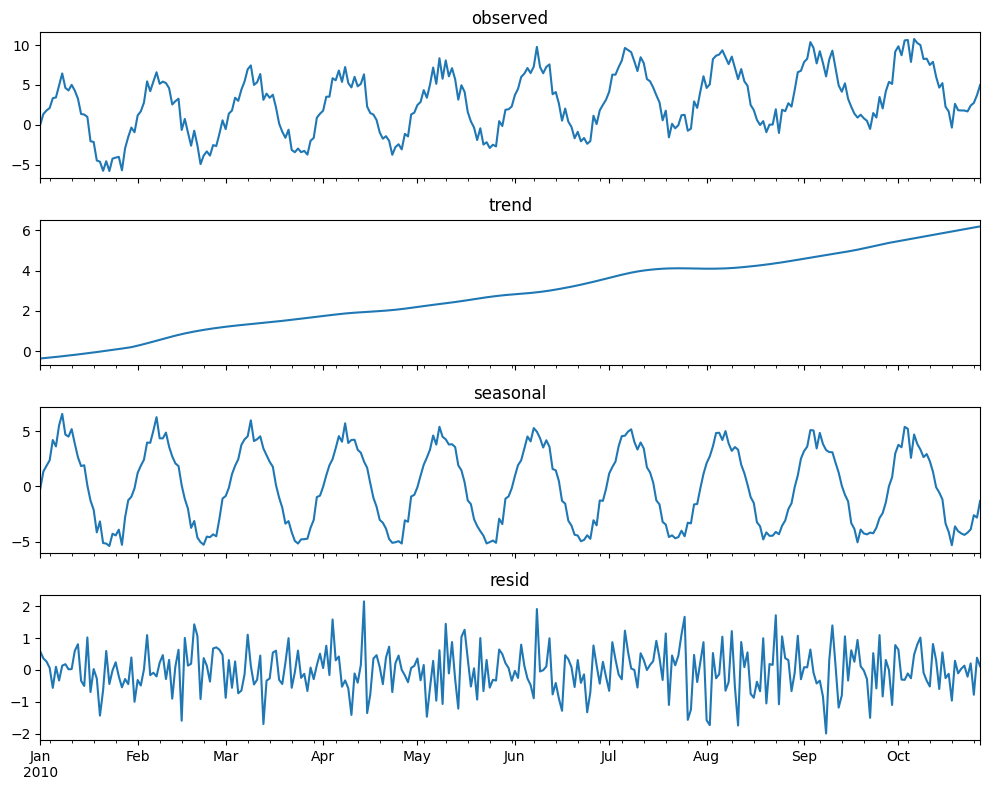

In [7]:
stl = stl_decompose(seasonal_series, period=30)

print(f"trend strength    : {stl['statistic']['trend_strength']:.3f}")
print(f"seasonal strength : {stl['statistic']['seasonal_strength']:.3f}")
print(f"=> {stl['conclusion']}")

fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)
seasonal_series.plot(ax=axes[0], title="observed")
stl['components']['trend'].plot(ax=axes[1], title="trend")
stl['components']['seasonal'].plot(ax=axes[2], title="seasonal")
stl['components']['resid'].plot(ax=axes[3], title="resid")
plt.tight_layout()
plt.show()

## 6. Build the test-results DataFrame

This is the pattern for the real EDA notebook: every test result is a dict, list of dicts → DataFrame, one row per (series, test) pair. STL's `components` key gets dropped so the schema stays uniform.

In [8]:
# Drop STL's components key — it doesn't belong in a tabular results frame
stl_row = {k: v for k, v in stl.items() if k != "components"}

results = [adf_wn, adf_rw, adf_tr, kpss_wn, kpss_rw, arch_wn, arch_ar, joh, stl_row]
results_df = pd.DataFrame(results)
results_df

,series,test_name,statistic,p_value,critical_values,null,conclusion
0,white_noise,ADF,-7.236821,1.929854e-10,"{'1%': -3.4529449243622383, '5%': -2.871489553...",unit root (non-stationary),stationary
1,random_walk,ADF,-0.541759,8.836067e-01,"{'1%': -3.4524113009049935, '5%': -2.871255412...",unit root (non-stationary),non-stationary
2,trend_series,ADF,-18.675563,0.000000e+00,"{'1%': -3.989370928165566, '5%': -3.4252763821...",unit root (non-stationary),stationary
3,white_noise,KPSS(c),0.134709,1.000000e-01,"{'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%...",level-stationary,level-stationary
4,random_walk,KPSS(c),1.51085,1.000000e-02,"{'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%...",level-stationary,non-stationary
5,white_noise,ARCH-LM(12),8.83362,7.170720e-01,"{'1%': 26.216967305535853, '5%': 21.0260698174...",no ARCH effects (homoskedastic),no ARCH effects
6,arch_series,ARCH-LM(12),58.127294,4.942705e-08,"{'1%': 26.216967305535853, '5%': 21.0260698174...",no ARCH effects (homoskedastic),ARCH effects present
7,"[x, y]",Johansen-trace,"{'r<=0': 128.22328975646008, 'r<=1': 0.6290444...",NaN,"{'r<=0': {'10%': 13.4294, '5%': 15.4943, '1%':...",cointegration rank <= r (sequentially for r = ...,estimated rank = 1 at alpha=0.05
8,seasonal_series,STL,"{'trend_strength': 0.8707465495418785, 'season...",NaN,None,None,strong trend; strong seasonality


## 7. Export to CSV

The `statistic`, `critical_values`, and (for Johansen) `series` columns contain dicts or lists. CSV can't store those natively, so we JSON-serialize them on the way out. The values are still readable, and you can `json.loads` them back on the way in.

In [9]:
csv_df = results_df.copy()
for col in ["statistic", "critical_values", "series"]:
    csv_df[col] = csv_df[col].apply(
        lambda v: json.dumps(v) if isinstance(v, (dict, list)) else v
    )

csv_df.to_csv("eda_test_results.csv", index=False)
print("Saved eda_test_results.csv")
csv_df

Saved eda_test_results.csv


,series,test_name,statistic,p_value,critical_values,null,conclusion
0,white_noise,ADF,-7.236821,1.929854e-10,"{""1%"": -3.4529449243622383, ""5%"": -2.871489553...",unit root (non-stationary),stationary
1,random_walk,ADF,-0.541759,8.836067e-01,"{""1%"": -3.4524113009049935, ""5%"": -2.871255412...",unit root (non-stationary),non-stationary
2,trend_series,ADF,-18.675563,0.000000e+00,"{""1%"": -3.989370928165566, ""5%"": -3.4252763821...",unit root (non-stationary),stationary
3,white_noise,KPSS(c),0.134709,1.000000e-01,"{""10%"": 0.347, ""5%"": 0.463, ""2.5%"": 0.574, ""1%...",level-stationary,level-stationary
4,random_walk,KPSS(c),1.51085,1.000000e-02,"{""10%"": 0.347, ""5%"": 0.463, ""2.5%"": 0.574, ""1%...",level-stationary,non-stationary
5,white_noise,ARCH-LM(12),8.83362,7.170720e-01,"{""1%"": 26.216967305535853, ""5%"": 21.0260698174...",no ARCH effects (homoskedastic),no ARCH effects
6,arch_series,ARCH-LM(12),58.127294,4.942705e-08,"{""1%"": 26.216967305535853, ""5%"": 21.0260698174...",no ARCH effects (homoskedastic),ARCH effects present
7,"[""x"", ""y""]",Johansen-trace,"{""r<=0"": 128.22328975646008, ""r<=1"": 0.6290444...",NaN,"{""r<=0"": {""10%"": 13.4294, ""5%"": 15.4943, ""1%"":...",cointegration rank <= r (sequentially for r = ...,estimated rank = 1 at alpha=0.05
8,seasonal_series,STL,"{""trend_strength"": 0.8707465495418785, ""season...",NaN,None,None,strong trend; strong seasonality


# Structural Breaks Check

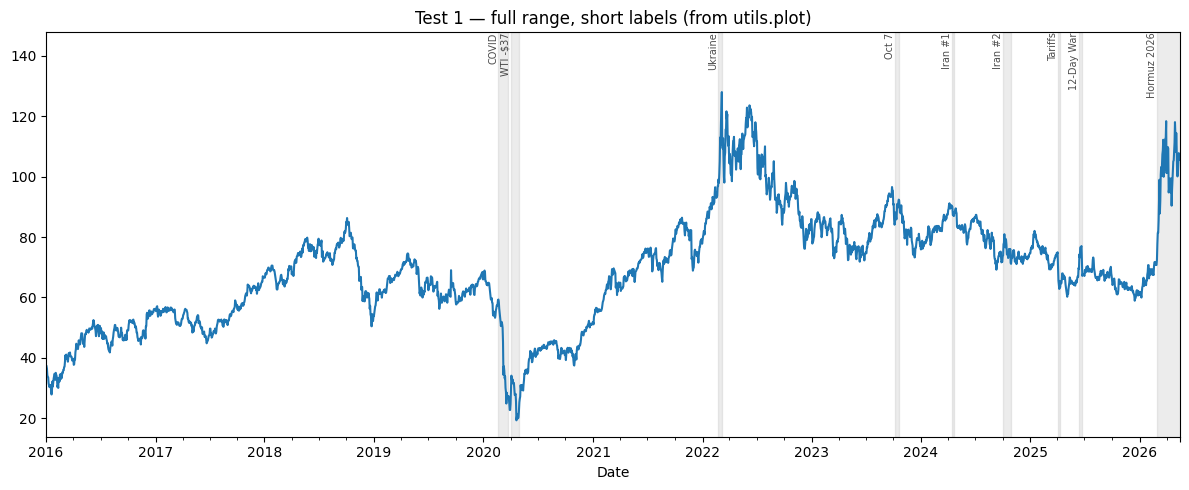

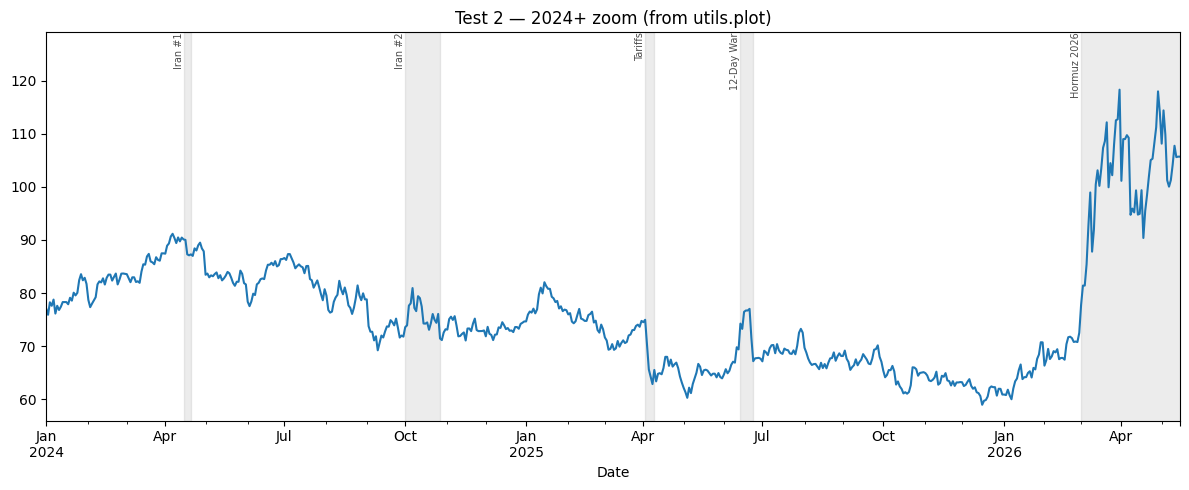

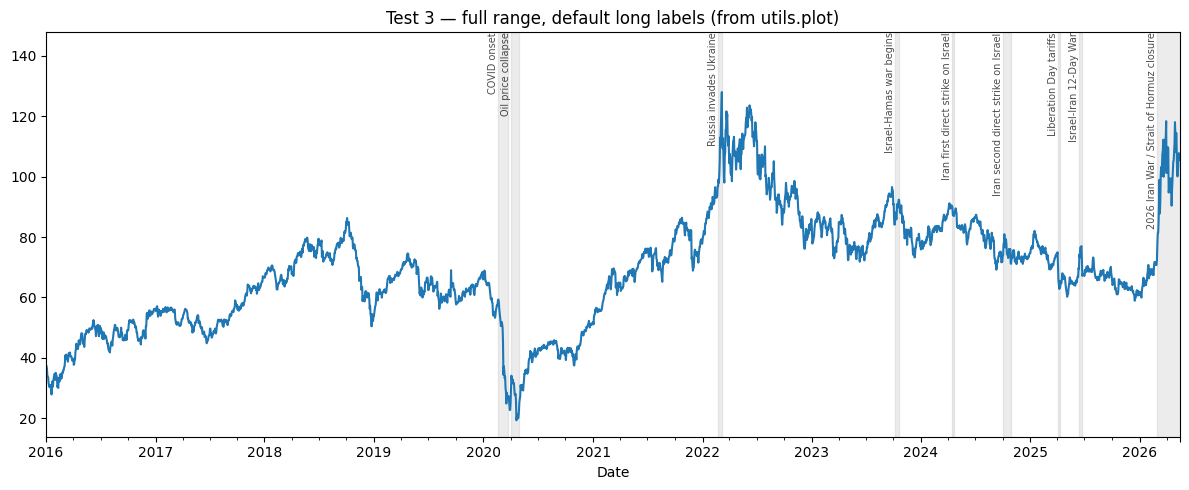

In [17]:
# === Verify utils/plot.py works when imported ===

import matplotlib.pyplot as plt
import pandas as pd
from utils.plot import overlay_breaks, SHORT_BREAK_LABELS

breaks = pd.read_csv("data/quality/structural_breaks.csv",
                     parse_dates=["start_date", "end_date"])
prices = pd.read_parquet("data/processed/prices.parquet")
brent = prices["Brent"]

# Test 1 — full range, short labels
fig, ax = plt.subplots(figsize=(12, 5))
brent.plot(ax=ax)
overlay_breaks(ax, breaks, short_labels=SHORT_BREAK_LABELS)
ax.set_title("Test 1 — full range, short labels (from utils.plot)")
plt.tight_layout(); plt.show()

# Test 2 — 2024+ zoom, with date_range
fig, ax = plt.subplots(figsize=(12, 5))
brent_zoom = brent.loc["2024":]
brent_zoom.plot(ax=ax)
overlay_breaks(
    ax, breaks,
    short_labels=SHORT_BREAK_LABELS,
    date_range=(brent_zoom.index.min(), brent_zoom.index.max()),
)
ax.set_title("Test 2 — 2024+ zoom (from utils.plot)")
plt.tight_layout(); plt.show()

# Test 3 — full range, long labels
fig, ax = plt.subplots(figsize=(12, 5))
brent.plot(ax=ax)
overlay_breaks(ax, breaks)
ax.set_title("Test 3 — full range, default long labels (from utils.plot)")
plt.tight_layout(); plt.show()